In [6]:
from ucimlrepo import fetch_ucirepo

#fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

#data (as pandas dataframe)
x = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

In [7]:
import pandas as pd
from typing import Union

def preview_dataset(
    features: pd.DataFrame,
    targets: Union[pd.DataFrame, pd.Series],
    n: int = 5,
) -> None:
    print("=== Dataset preview (UCI id=17) ===")
    print(f"X shape: {features.shape}")
    print(f"y shape: {getattr(targets, 'shape', None)}")
    print("\n--- X columns ---")
    print(list(features.columns))

    print(f"\n--- First {n} rows of X ---")
    print(features.head(n))

    print(f"\n--- First {n} rows of y ---")
    try:
        print(targets.head(n))
    except AttributeError:
        print(pd.Series(targets).head(n))

    y_series = targets.iloc[:, 0] if isinstance(targets, pd.DataFrame) else pd.Series(targets)
    print("\n--- y distribution ---")
    print(y_series.value_counts(dropna=False))

    print("\n--- Missing values ---")
    print("X missing per column (top 10):")
    print(features.isna().sum().sort_values(ascending=False).head(10))
    print("y missing:")
    print(y_series.isna().sum())


def export_dataset_csv(
    features: pd.DataFrame,
    targets: Union[pd.DataFrame, pd.Series],
    output_path: str = "breast_cancer_wisconsin_diagnostic.csv",
) -> str:
    if isinstance(targets, pd.DataFrame):
        dataset = pd.concat([features, targets], axis=1)
    else:
        dataset = features.copy()
        dataset["target"] = targets.values

    dataset.to_csv(output_path, index=False)
    return output_path

In [8]:
# Preview do dataset
preview_dataset(x, y, n=5)

# Exporta para CSV (na pasta do projeto)
csv_path = export_dataset_csv(x, y, output_path="breast_cancer_wisconsin_diagnostic.csv")
print(f"\nCSV gerado em: {csv_path}")

=== Dataset preview (UCI id=17) ===
X shape: (569, 30)
y shape: (569, 1)

--- X columns ---
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']

--- First 5 rows of X ---
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  con

In [9]:
from sklearn.model_selection import train_test_split

# Garante que y seja 1D para stratify
y_series = y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y

# 1) Separa 60% treino e 40% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    x,
    y_series,
    test_size=0.40,
    random_state=42,
    stratify=y_series,
    shuffle=True,
 )

# 2) Do temporário (40%), separa 10% validação e 30% teste
#    10/40 = 0.25 (validação) e 30/40 = 0.75 (teste)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.75,
    random_state=42,
    stratify=y_temp,
    shuffle=True,
 )

print("Shapes:")
print(f"  Treino:     X={X_train.shape}, y={y_train.shape}")
print(f"  Validação:  X={X_val.shape}, y={y_val.shape}")
print(f"  Teste:      X={X_test.shape}, y={y_test.shape}")

print("\nProporções (aprox):")
total = len(x)
print(f"  Treino:     {len(X_train)/total:.2%}")
print(f"  Validação:  {len(X_val)/total:.2%}")
print(f"  Teste:      {len(X_test)/total:.2%}")

print("\nDistribuição de classes (y):")
print("Treino:\n", y_train.value_counts(normalize=True))
print("\nValidação:\n", y_val.value_counts(normalize=True))
print("\nTeste:\n", y_test.value_counts(normalize=True))

Shapes:
  Treino:     X=(341, 30), y=(341,)
  Validação:  X=(57, 30), y=(57,)
  Teste:      X=(171, 30), y=(171,)

Proporções (aprox):
  Treino:     59.93%
  Validação:  10.02%
  Teste:      30.05%

Distribuição de classes (y):
Treino:
 Diagnosis
B    0.627566
M    0.372434
Name: proportion, dtype: float64

Validação:
 Diagnosis
B    0.631579
M    0.368421
Name: proportion, dtype: float64

Teste:
 Diagnosis
B    0.625731
M    0.374269
Name: proportion, dtype: float64


In [10]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# Lê o CSV completo (gerado anteriormente)
input_csv = Path("breast_cancer_wisconsin_diagnostic.csv")
df = pd.read_csv(input_csv)

# Descobre a coluna alvo (target)
if "Diagnosis" in df.columns:
    target_col = "Diagnosis"
elif "target" in df.columns:
    target_col = "target"
else:
    target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y_full = df[target_col]

# 1) 60% treino + 40% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_full,
    test_size=0.40,
    random_state=42,
    stratify=y_full,
    shuffle=True,
 )

# 2) Do temporário (40%), 10% validação e 30% teste
#    10/40 = 0.25 (validação) e 30/40 = 0.75 (teste)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.75,
    random_state=42,
    stratify=y_temp,
    shuffle=True,
 )

# Junta features + target para salvar em CSV
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

train_csv = Path("breast_cancer_train_60.csv")
val_csv = Path("breast_cancer_val_10.csv")
test_csv = Path("breast_cancer_test_30.csv")

df_train.to_csv(train_csv, index=False)
df_val.to_csv(val_csv, index=False)
df_test.to_csv(test_csv, index=False)

print("Arquivos gerados:")
print("-", train_csv, "->", df_train.shape)
print("-", val_csv, "->", df_val.shape)
print("-", test_csv, "->", df_test.shape)

Arquivos gerados:
- breast_cancer_train_60.csv -> (341, 31)
- breast_cancer_val_10.csv -> (57, 31)
- breast_cancer_test_30.csv -> (171, 31)


In [11]:
import math
from collections import defaultdict
from pathlib import Path

import pandas as pd

# =============================
# KNN (do zero, sem scikit-learn/numpy)
# =============================

def _as_float_matrix(df_features: pd.DataFrame) -> list[list[float]]:
    # Converte DataFrame -> lista de listas de float
    rows: list[list[float]] = []
    for row in df_features.itertuples(index=False, name=None):
        rows.append([float(v) for v in row])
    return rows


def _standardize_fit(X: list[list[float]]) -> tuple[list[float], list[float]]:
    # Retorna (means, stds) por coluna, calculados no treino
    n_rows = len(X)
    if n_rows == 0:
        raise ValueError("X vazio")
    n_cols = len(X[0])
    means = [0.0] * n_cols
    for r in range(n_rows):
        for c in range(n_cols):
            means[c] += X[r][c]
    means = [m / n_rows for m in means]

    variances = [0.0] * n_cols
    for r in range(n_rows):
        for c in range(n_cols):
            diff = X[r][c] - means[c]
            variances[c] += diff * diff
    # variância populacional (divide por n). Para KNN não faz muita diferença usar n-1.
    stds = [math.sqrt(v / n_rows) for v in variances]
    # evita divisão por zero
    stds = [s if s > 0 else 1.0 for s in stds]
    return means, stds


def _standardize_transform(
    X: list[list[float]],
    means: list[float],
    stds: list[float],
) -> list[list[float]]:
    Xz: list[list[float]] = []
    for row in X:
        Xz.append([(row[i] - means[i]) / stds[i] for i in range(len(row))])
    return Xz


def _euclidean_sq(a: list[float], b: list[float]) -> float:
    # Distância euclidiana ao quadrado (mais rápida, não precisa sqrt)
    s = 0.0
    for i in range(len(a)):
        d = a[i] - b[i]
        s += d * d
    return s


def knn_predict_one(
    x_query: list[float],
    X_train: list[list[float]],
    y_train: list[str],
    k: int,
) -> str:
    if k <= 0:
        raise ValueError("k deve ser >= 1")
    if k > len(X_train):
        raise ValueError("k maior que o tamanho do treino")

    # Calcula todas as distâncias (O(n)) e pega os k vizinhos mais próximos (ordena)
    distances = []  # lista de (dist, label)
    for xi, yi in zip(X_train, y_train):
        distances.append((_euclidean_sq(x_query, xi), yi))
    distances.sort(key=lambda t: t[0])
    neighbors = distances[:k]

    # Votação por maioria. Desempate: menor distância média.
    votes = defaultdict(lambda: [0, 0.0])  # label -> [count, sum_dist]
    for dist, label in neighbors:
        votes[label][0] += 1
        votes[label][1] += dist

    # escolhe o label com maior count; em empate, menor distância média
    best_label = None
    best_key = None
    for label, (count, sum_dist) in votes.items():
        avg_dist = sum_dist / count
        key = (-count, avg_dist)
        if best_key is None or key < best_key:
            best_key = key
            best_label = label
    if best_label is None:
        # fallback (não deve acontecer)
        return neighbors[0][1]
    return best_label


def knn_predict(
    X_queries: list[list[float]],
    X_train: list[list[float]],
    y_train: list[str],
    k: int,
) -> list[str]:
    return [knn_predict_one(xq, X_train, y_train, k) for xq in X_queries]


def confusion_matrix(
    y_true: list[str],
    y_pred: list[str],
    labels: list[str] | None = None,
) -> tuple[list[str], list[list[int]]]:
    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred precisam ter o mesmo tamanho")

    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))

    index = {lab: i for i, lab in enumerate(labels)}
    m = [[0 for _ in labels] for _ in labels]  # linhas=true, colunas=pred
    for yt, yp in zip(y_true, y_pred):
        i = index[yt]
        j = index[yp]
        m[i][j] += 1
    return labels, m


def accuracy_from_confusion(m: list[list[int]]) -> float:
    total = 0
    correct = 0
    for i in range(len(m)):
        for j in range(len(m[i])):
            total += m[i][j]
            if i == j:
                correct += m[i][j]
    return (correct / total) if total else 0.0


def print_confusion(labels: list[str], m: list[list[int]], title: str = "") -> None:
    if title:
        print(title)
    header = "true\\pred".ljust(10) + " " + " ".join(lab.rjust(6) for lab in labels)
    print(header)
    for lab, row in zip(labels, m):
        print(lab.ljust(10) + " " + " ".join(str(v).rjust(6) for v in row))


# =============================
# Carrega os CSVs e roda o KNN
# =============================

train_path = Path("breast_cancer_train_60.csv")
val_path = Path("breast_cancer_val_10.csv")
test_path = Path("breast_cancer_test_30.csv")

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

# coluna alvo
if "Diagnosis" in df_train.columns:
    target_col = "Diagnosis"
elif "target" in df_train.columns:
    target_col = "target"
else:
    target_col = df_train.columns[-1]

X_train_df = df_train.drop(columns=[target_col])
y_train_list = [str(v) for v in df_train[target_col].tolist()]

X_val_df = df_val.drop(columns=[target_col])
y_val_list = [str(v) for v in df_val[target_col].tolist()]

X_test_df = df_test.drop(columns=[target_col])
y_test_list = [str(v) for v in df_test[target_col].tolist()]

# matriz de floats
X_train_list = _as_float_matrix(X_train_df)
X_val_list = _as_float_matrix(X_val_df)
X_test_list = _as_float_matrix(X_test_df)

# normaliza baseado no treino
means, stds = _standardize_fit(X_train_list)
X_train_z = _standardize_transform(X_train_list, means, stds)
X_val_z = _standardize_transform(X_val_list, means, stds)
X_test_z = _standardize_transform(X_test_list, means, stds)

# escolha de k (simples): testa alguns k na validação e pega o melhor
candidate_ks = [1, 3, 5, 7, 9, 11, 13, 15]
best_k = None
best_acc = -1.0
for k in candidate_ks:
    if k > len(X_train_z):
        continue
    y_val_pred_tmp = knn_predict(X_val_z, X_train_z, y_train_list, k)
    labels_tmp, cm_tmp = confusion_matrix(y_val_list, y_val_pred_tmp)
    acc = accuracy_from_confusion(cm_tmp)
    print(f"k={k:2d} | acc_val={acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_k = k

print("\nMelhor k na validação:", best_k, "(acc_val=", f"{best_acc:.4f}", ")")

# Matriz de confusão na validação (best_k)
y_val_pred = knn_predict(X_val_z, X_train_z, y_train_list, best_k)
labels, cm_val = confusion_matrix(y_val_list, y_val_pred)
print()
print_confusion(labels, cm_val, title="Matriz de confusão (Validação)")
print("Acurácia (Validação) =", f"{accuracy_from_confusion(cm_val):.4f}")

# Matriz de confusão no teste (best_k)
y_test_pred = knn_predict(X_test_z, X_train_z, y_train_list, best_k)
labels, cm_test = confusion_matrix(y_test_list, y_test_pred, labels=labels)
print()
print_confusion(labels, cm_test, title="Matriz de confusão (Teste)")
print("Acurácia (Teste) =", f"{accuracy_from_confusion(cm_test):.4f}")

k= 1 | acc_val=0.9474
k= 3 | acc_val=0.9649
k= 5 | acc_val=0.9649
k= 7 | acc_val=0.9474
k= 9 | acc_val=0.9298
k=11 | acc_val=0.9474
k=13 | acc_val=0.9298
k=15 | acc_val=0.9474

Melhor k na validação: 3 (acc_val= 0.9649 )

Matriz de confusão (Validação)
true\pred       B      M
B              36      0
M               2     19
Acurácia (Validação) = 0.9649

Matriz de confusão (Teste)
true\pred       B      M
B             107      0
M               7     57
Acurácia (Teste) = 0.9591


Imagem salva em: confusion_val.png


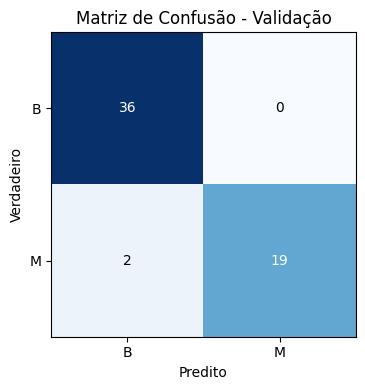

Imagem salva em: confusion_test.png


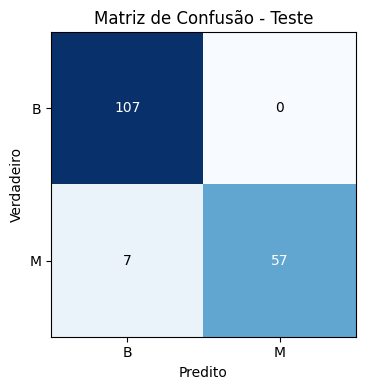

In [12]:
# geração de imagens das matrizes de confusão
import matplotlib.pyplot as plt

def plot_confusion_matrix_image(
    labels: list[str],
    cm: list[list[int]],
    title: str,
    filename: str | None = None,
 ) -> None:
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Verdadeiro")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # anotações dentro das células
    max_val = max(max(row) for row in cm) if cm else 0
    threshold = max_val / 2 if max_val else 0
    for i in range(len(cm)):
        for j in range(len(cm[i])):
            val = cm[i][j]
            color = "white" if val > threshold else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=color)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=200, bbox_inches="tight")
        print(f"Imagem salva em: {filename}")
    plt.show()


plot_confusion_matrix_image(labels, cm_val, "Matriz de Confusão - Validação", "confusion_val.png")
plot_confusion_matrix_image(labels, cm_test, "Matriz de Confusão - Teste", "confusion_test.png")